## 1. Importación de Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import os
import mlflow
import mlflow.sklearn
from sklearn.base import clone
import warnings
import logging
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger("mlflow").setLevel(logging.ERROR)

## 2. Carga de Datos y Preparación de Variables

In [2]:
# 1. CARGA DE DATOS
df = pd.read_parquet('../output/dataset_unificado.parquet')

# 2. PREPARACIÓN DE FEATURES Y TARGET
# El target es 'precio'
X = df.drop(columns=['precio'])
y = df['precio']

## 3. Aplicamos ingenieria de caracteristicas

In [3]:
# 1. Separamos las columnas por tipo
cols_num = ['superficie_total', 'ambientes', 'antiguedad', 'cochera', 'balcon', 'piscina']
cols_cat = ['barrio', 'tipo']

# 2. Creamos el preprocesador robusto
preprocessor_base = ColumnTransformer(
    transformers=[
        # Para números: Imputamos nulos (por las dudas) y ESCALAMOS
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), cols_num),
        
        # Para categorías: Imputamos y aplicamos OneHot
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cols_cat)
    ]
)

## 4. Dividimos el dataset para el Train y Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Definimos Modelos e Hiperparametros

In [5]:
dict_algoritmos = {
    "Linear_Regression": LinearRegression(),
    "Random_Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1)
}

## 6. Entrenamiento, Validación Cruzada y Evaluación de Modelos

In [6]:
# 1. Configuración de Rutas y MLflow (Blindado para Windows)
base_dir = Path(os.getcwd()).parent
mlruns_dir = base_dir / "mlruns"

if not mlruns_dir.exists():
    mlruns_dir.mkdir(parents=True)

# Usamos as_uri() para que MLflow no se confunda con las barras de Windows
tracking_uri = mlruns_dir.as_uri()
mlflow.set_tracking_uri(tracking_uri)

experiment_name = "Analisis_Prediccion_Propiedata"

try:
    # Intentamos obtener el ID si ya existe
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp:
        experiment_id = exp.experiment_id
        print(f"Usando experimento existente: {experiment_id}")
    else:
        # Si no existe, lo creamos
        experiment_id = mlflow.create_experiment(experiment_name)
        print(f"Nuevo experimento creado: {experiment_id}")
except Exception:
    # Si hay conflicto con la carpeta .trash, recuperamos el ID directamente
    exp = mlflow.get_experiment_by_name(experiment_name)
    experiment_id = exp.experiment_id if exp else "0"

mlflow.set_experiment(experiment_name)

# 2. Bucle de Entrenamiento y Tracking
resultados = []
print(f"Tracking activo en: {mlruns_dir}")
print("-" * 50)

for nombre, modelo in dict_algoritmos.items():
    with mlflow.start_run(run_name=nombre, experiment_id=experiment_id):
        
        # Clonamos el preprocesador (que ahora tiene el Imputer para evitar NaNs)
        pre_clean = clone(preprocessor_base)
        pipe = Pipeline([('pre', pre_clean), ('reg', modelo)])
        
        # Cross-validation para evaluar estabilidad (R2_CV)
        cv_res = cross_validate(pipe, X_train, y_train, cv=5, scoring='r2')
        r2_cv = cv_res['test_score'].mean()
        
        # Entrenamiento final con el set de entrenamiento completo
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        # Cálculo de métricas de precisión
        metrics = {
            "R2_CV": r2_cv,
            "R2_Test": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred)
        }
        
        # Logueo de parámetros del algoritmo (hiperparámetros)
        if hasattr(modelo, 'get_params'):
            mlflow.log_params(modelo.get_params())
        
        # Registro de métricas y del modelo (Pipeline completo) en MLflow
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipe, artifact_path="pipeline_model")
        
        # Guardamos en la lista local para la tabla comparativa final
        resultados.append({"Modelo": nombre, **metrics})
        print(f"{nombre:20} finalizado | R2_Test: {metrics['R2_Test']:.4f}")

# 3. Visualización de Resultados Finales
print("-" * 50)
df_resultados = pd.DataFrame(resultados).sort_values(by='R2_Test', ascending=False)
display(df_resultados)

Usando experimento existente: 955756775802534900
Tracking activo en: c:\Users\eazam\Desktop\prueba-tecnica-ds-propiedata\prueba-tecnica-ds-propiedata\mlruns
--------------------------------------------------
Linear_Regression    finalizado | R2_Test: 0.7115
Random_Forest        finalizado | R2_Test: 0.7927
XGBoost              finalizado | R2_Test: 0.8023
LightGBM             finalizado | R2_Test: 0.8053
--------------------------------------------------


,Modelo,R2_CV,R2_Test,MAE,RMSE,MAPE
3,LightGBM,0.777947,0.805284,199222.666787,301981.485164,0.205753
2,XGBoost,0.795646,0.802270,197366.562500,304309.858085,0.202687
1,Random_Forest,0.788689,0.792733,205053.152612,311561.842334,0.214847
0,Linear_Regression,0.678766,0.711533,247218.332653,367559.681952,0.280455


## 8. Comparativa de Modelos

🏆 Mejor Modelo Detectado: LightGBM
------------------------------
🧐 TOP 5 PROPIEDADES CON MAYOR ERROR:


,barrio,tipo,superficie_total,Precio_Real,Precio_Predicho,Error_Porcentual
7727,Belgrano,Departamento,167,5712000,2.708347e+06,52.584954
2036,Palermo,Ph,107,3954925,1.948142e+06,50.741359
6458,Villa Urquiza,Casa,183,2648925,4.484071e+06,69.278902
5636,Villa Crespo,Departamento,157,4231000,2.613736e+06,38.224151
3639,Recoleta,Casa,176,959000,2.486626e+06,159.293652


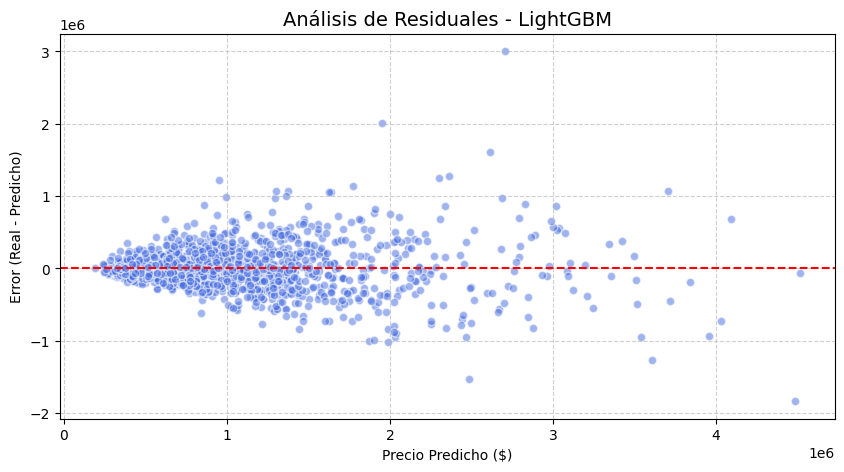

In [ ]:
mejor_resultado = max(resultados, key=lambda x: x['R2_Test'])
mejor_nombre = mejor_resultado['Modelo']

mejor_pipeline = Pipeline([
    ('pre', clone(preprocessor_base)), 
    ('reg', dict_algoritmos[mejor_nombre])
])
mejor_pipeline.fit(X_train, y_train)

y_pred_mejor = mejor_pipeline.predict(X_test)

test_results = X_test.copy()
test_results['Precio_Real'] = y_test
test_results['Precio_Predicho'] = y_pred_mejor
test_results['Error_Absoluto'] = abs(test_results['Precio_Real'] - test_results['Precio_Predicho'])
test_results['Error_Porcentual'] = (test_results['Error_Absoluto'] / test_results['Precio_Real']) * 100

display(test_results.sort_values(by='Error_Absoluto', ascending=False).head(5)[
    ['barrio', 'tipo', 'superficie_total', 'Precio_Real', 'Precio_Predicho', 'Error_Porcentual']
])

plt.figure(figsize=(10, 5))
residuos = y_test - y_pred_mejor
plt.scatter(y_pred_mejor, residuos, alpha=0.5, color='royalblue', edgecolor='w')
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Análisis de Residuales - {mejor_nombre}', fontsize=14)
plt.xlabel('Precio Predicho ($)')
plt.ylabel('Error (Real - Predicho)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()